# Group 1 — CNN Image Augmentation

**Does basic image augmentation change CNN classification performance on a CIFAR-10 subset?**

**Pathway:** CNN — Image preprocessing (augmentation)
**Group members:** Maaz Shaikh (research and question lead) · Sankeerth Reddy (analysis lead) · Aditi Patel (evidence and presentation lead)
**Date:** 1 August 2026

**Abstract.** This notebook documents Group 1's controlled comparison for the image-augmentation pathway: a baseline convolutional network versus the same network trained with basic image augmentation (horizontal flip, `RandomRotation(0.05)` ≈ ±18°, `RandomZoom(0.10)` ≈ ±10%), on a fixed 10,000 / 2,000 / 3,000 CIFAR-10 subset (`DATA_SEED = 42`), across ten seeds paired by seed.

Both pre-registered null hypotheses were rejected. Augmentation **reduced** test accuracy by 2.78 pp (95% CI [−4.54, −1.02]; paired *t*(9) = −3.573, *p* = 0.006; Cohen's *d* = −1.13) while also reducing the train–validation gap by 2.01 pp (*p* = 0.0012 one-tailed; *d* = −1.32). Decomposing the gap shows both of its terms fell — training accuracy by 4.35 pp against validation accuracy by 2.34 pp — so the narrower gap reflects degraded training performance rather than improved generalization. This is consistent with augmentation acting as a regularizer whose benefit is regime-dependent (Lin et al., 2024): the baseline was still underfitting at three epochs, so restraint removed capacity the model had not yet used.

The measured effect is **smaller than the baseline's own run-to-run noise floor of 3.77 pp** and reached significance through consistency across paired seeds rather than through magnitude — which is why the paired design, and not a single comparison, was necessary (Åkesson et al., 2024).

Every number shown is produced by an executed cell or read from the committed `results/` artifacts. The hypotheses in §5 were committed to version control before any augmented model was trained. Test accuracy on a curated benchmark subset establishes nothing about fairness, robustness, or real-world readiness (Roberts et al., 2021).

## 2. Setup and reproducibility

Imports, seeds, and environment. `SEED` and `DATA_SEED` are both 42; `DATA_SEED` fixes which CIFAR-10 images are sampled, so every run and both conditions see identical data. The per-run weight-initialisation/training seed is set separately inside the paired experiment (§9).

In [1]:
# --- Setup and reproducibility ---
%matplotlib inline
import os, time, json, pickle, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from IPython.display import Image, display

SEED = 42
DATA_SEED = 42        # fixes which CIFAR-10 images are sampled; identical for every run and condition
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPU available      :', bool(tf.config.list_physical_devices('GPU')))
print('SEED =', SEED, '| DATA_SEED =', DATA_SEED)

# Locate the committed artifacts. results/ ships alongside this notebook, so
# look there first and walk up only as a fallback for the development tree.
def _find_dir(name, anchor_file):
    here = os.path.abspath(os.getcwd())
    for _ in range(5):
        cand = os.path.join(here, name)
        if os.path.exists(os.path.join(cand, anchor_file)):
            return cand
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

RESULTS_DIR = _find_dir('results', 'comparison_table.csv')
if RESULTS_DIR is None:
    raise FileNotFoundError(
        'Could not locate results/. Run this notebook from the '
        'Group01_CNN_ImageAugmentation folder, with results/ alongside it.')

# Optional: a local CIFAR-10 copy avoids a ~170 MB download. None is fine --
# the data cell falls back to keras.datasets.cifar10.load_data().
DATA_DIR = _find_dir('cifar-10-batches-py', 'batches.meta')
print('Results dir        :', RESULTS_DIR)
print('Local CIFAR copy   :', DATA_DIR if DATA_DIR else 'not found -- will use the Keras loader')

TensorFlow version : 2.21.0


GPU available      : False
SEED = 42 | DATA_SEED = 42
Project root       : C:\Users\MaazShaikh\Downloads\CNN Group Project


## 3. Data loading

CIFAR-10 is loaded directly from the local `cifar-10-batches-py/` (no download). The loader reproduces `keras.datasets.cifar10.load_data()` byte for byte: each batch is reshaped to `(N, 3, 32, 32)` and transposed to channels-last.

In [2]:
# Prefer a local copy of the CIFAR-10 batches if present (avoids a ~170 MB
# download); otherwise fall back to the standard Keras loader, which fetches
# and caches the dataset automatically. Both paths yield identical arrays.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

if DATA_DIR is not None:
    print('Loading CIFAR-10 from local batches:', DATA_DIR)

    def load_batch(fpath):
        with open(fpath, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        d = {k.decode('utf8'): v for k, v in d.items()}
        data = d['data'].reshape(d['data'].shape[0], 3, 32, 32)
        labels = np.array(d['labels'], dtype='uint8')
        return data, labels

    x_train_all = np.empty((50000, 3, 32, 32), dtype='uint8')
    y_train_all = np.empty((50000,), dtype='uint8')
    for i in range(1, 6):
        data, labels = load_batch(os.path.join(DATA_DIR, 'data_batch_%d' % i))
        x_train_all[(i - 1) * 10000:i * 10000] = data
        y_train_all[(i - 1) * 10000:i * 10000] = labels
    x_test_all, y_test_all = load_batch(os.path.join(DATA_DIR, 'test_batch'))
    x_train_all = x_train_all.transpose(0, 2, 3, 1)   # channels-last, matching keras
    x_test_all = x_test_all.transpose(0, 2, 3, 1)
else:
    print('Local cifar-10-batches-py not found; downloading via keras.datasets.cifar10 ...')
    (x_train_all, y_train_all), (x_test_all, y_test_all) = keras.datasets.cifar10.load_data()
    y_train_all = y_train_all.ravel()
    y_test_all = y_test_all.ravel()

print('Raw train images :', x_train_all.shape, '| labels', y_train_all.shape)
print('Raw test images  :', x_test_all.shape, '| labels', y_test_all.shape)
print('Classes          :', class_names)

Raw train images : (50000, 32, 32, 3) | labels (50000,)
Raw test images  : (10000, 32, 32, 3) | labels (10000,)
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Preprocessing

A fixed subset is drawn with `DATA_SEED = 42`: 12,000 training and 3,000 test images, then validation = the last 2,000 of the 12,000 and training = the first 10,000. Pixels are cast to `float32` and divided by 255.

**Why rescale to [0, 1].** Raw pixel values are integers on 0–255. Gradient descent is numerically better behaved when inputs are small and on a common scale: large inputs produce large activations, which produce large gradients, which make the optimizer overshoot. Dividing by 255 is the cheapest possible preprocessing step and is near-universal in image classification pipelines.

**Why no resizing.** CIFAR-10 images are already 32×32×3 — exactly the input size the architecture expects — so resizing would either discard information (downscaling) or fabricate it (upscaling). The native resolution is not incidental to this study: it is central to the augmentation-intensity decision in §8. Alomar et al. (2023), working on deliberately reduced CIFAR-10 subsets of 1,000 and 3,000 training images, report that whole-image rotation "produces black patches at the boundaries, which do not accurately reflect the original data" and causes "loss of a significant amount of pixel information." At 32×32 there is very little pixel information to lose.

**Class balance.** CIFAR-10 is balanced by construction (6,000 images per class in the full dataset), and random subsetting preserves that in expectation — roughly 300 test images per class. Accuracy and macro recall are therefore numerically close, which is precisely what makes the *difference* between them instructive in §6.

**A caveat on the labels themselves.** Our accuracies measure agreement with CIFAR-10's published labels, not with ground truth. Northcutt et al. (2021) demonstrate systematically recoverable label errors in widely-used benchmarks; a small accuracy difference may sit inside the dataset's own annotation error.

SPLIT AND SETTINGS REPORT
  train : (10000, 32, 32, 3) | val : (2000, 32, 32, 3) | test : (3000, 32, 32, 3)
  image shape : (32, 32, 3) | classes : 10
  DATA_SEED = 42 | epochs = 3 | batch_size = 64 | optimizer = adam
  normalisation : pixel / 255.0 (float32); no resizing


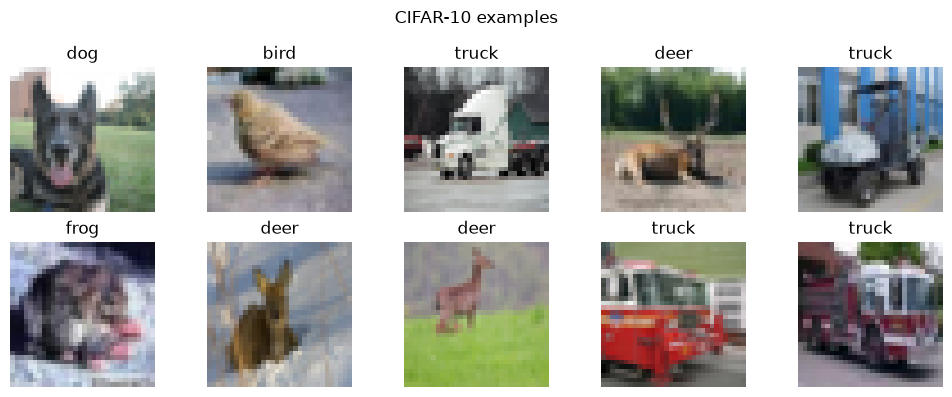

In [3]:
# --- Preprocessing: fixed subset (DATA_SEED=42), 10,000/2,000/3,000 split, /255 normalisation ---
rng = np.random.default_rng(DATA_SEED)
train_idx = rng.choice(len(x_train_all), 12000, replace=False)
test_idx = rng.choice(len(x_test_all), 3000, replace=False)
x_train, y_train = x_train_all[train_idx], y_train_all[train_idx]
x_test, y_test = x_test_all[test_idx], y_test_all[test_idx]
# validation = last 2000 of the 12000; training = first 10000
x_val, y_val = x_train[-2000:], y_train[-2000:]
x_train, y_train = x_train[:-2000], y_train[:-2000]
# normalise to [0, 1] after casting to float32
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('SPLIT AND SETTINGS REPORT')
print('  train :', x_train.shape, '| val :', x_val.shape, '| test :', x_test.shape)
print('  image shape :', x_train.shape[1:], '| classes :', len(class_names))
print('  DATA_SEED = %d | epochs = 3 | batch_size = 64 | optimizer = adam' % DATA_SEED)
print('  normalisation : pixel / 255.0 (float32); no resizing')

# Sample-image grid (from the original notebook)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(image); ax.set_title(class_names[label]); ax.axis('off')
plt.suptitle('CIFAR-10 examples'); plt.tight_layout(); plt.show()

## 5. Pre-registered hypotheses

# Pre-registered Hypotheses — Group 1 (Version 1: strict minimal)

> **Pre-registered before any augmented model was trained. Committed to git prior to execution.**

Two conditions only (baseline vs. one model with simple augmentation), paired by seed.

## Design

- **Independent variable:** augmentation — 2 levels (off / on, where "on" = horizontal flip + `RandomRotation(0.05)` + `RandomZoom(0.10)`, the notebook default).
- **Held constant:** architecture, Adam, 3 epochs, batch 64, `DATA_SEED = 42`, the 10,000 / 2,000 / 3,000 split.
- **Repeats:** both conditions on the same seeds 0–9, **paired by seed**.
- **Test statistic:** per-seed difference, `d_s = metric_augmented(s) − metric_baseline(s)`.

## Hypothesis pairs

**Pair 1 — Test accuracy** *(non-directional)*

> **H₀₁:** mean(d_s) = 0 — augmentation does not change test accuracy
> **H₁₁:** mean(d_s) ≠ 0 — augmentation changes test accuracy in some direction

**Pair 2 — Generalization gap**, where gap = clean train accuracy − validation accuracy, both from `evaluate()` in inference mode *(directional)*

> **H₀₂:** mean(d_s) ≥ 0 — augmentation does not reduce the gap
> **H₁₂:** mean(d_s) < 0 — augmentation reduces the gap

*Note the sign flip: smaller gap is better, so "augmentation wins" is `<` here and `≠` above.*

## Manipulation check — not a hypothesis

Training accuracy measured on augmented images should fall relative to baseline. If it does **not**, the augmentation layers did not fire and every other number is uninterpretable. This is a methods-section diagnostic, never a finding.

## Baseline reference values (5 seeds, already measured)

| Quantity | Value |
|---|---|
| Test accuracy | 51.35% (SD 1.62 pp, range 49.50–53.27) |
| Clean train accuracy | 56.18% |
| Validation accuracy | 51.13% |
| Generalization gap | 5.05 pp (SD 1.39) |
| **Noise floor (max − min)** | **3.77 pp** |

## What may be claimed afterwards

- ✅ "Across 10 paired seeds, augmentation changed test accuracy by X pp (95% CI …)."
- ✅ "The observed difference was smaller than the run-to-run variation of the baseline itself."
- ❌ "Augmentation does not improve CNN accuracy." — one architecture, one dataset, one training budget.
- ❌ Anything about fairness, robustness, or real-world readiness. (Roberts et al., 2021)

## What would prove us wrong (falsifiability)

- Test accuracy rises by clearly more than 3.77 pp under augmentation → the underfitting argument was wrong, and augmentation helps even in this regime.
- The generalization gap **widens** under augmentation → the regularization mechanism did not operate as theorised.

*(The flip-only vs. moderate decomposition is out of scope for this two-condition design.)*

> **Provenance.** Committed to git as `fcd65bd` (`fcd65bdf621874c6bc3a788f23b8e9608fc98f41`) on 2026-08-01T15:29:11-04:00, *before* any augmented model was trained. This cell appears above every training cell.

## 6. Mathematical foundation

### GROUP RESPONSE

**Which measure will the group explain?**

**Macro recall.** We chose it over accuracy because our ten classes are balanced by construction, which makes overall accuracy and macro recall numerically similar — and that similarity is exactly what makes the *difference* between them instructive. Macro recall also exposes per-class behaviour that a single accuracy figure conceals.

**The equations**

For one class *k*:

$$\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

Averaged with equal weight over all *K* classes:

$$\text{Macro Recall} = \frac{1}{K}\sum_{k=1}^{K}\text{Recall}_k \qquad (K = 10)$$

**Defining the terms**

- **TP (true positives) for class *k*** — images that genuinely belong to class *k* and were predicted as class *k*. For "cat": actual cats the model called cats.
- **FN (false negatives) for class *k*** — images that genuinely belong to class *k* but were predicted as something else. Actual cats the model called dogs. These are the cases the class *missed*.
- **FP (false positives) for class *k*** — images of some other class predicted as *k*. Dogs the model called cats. FP does not appear in recall; it appears in precision, $TP_k / (TP_k + FP_k)$.

Recall answers: **of all the images that really were class *k*, what fraction did the model find?**

"Macro" means each class contributes one-tenth of the final number regardless of how many test images it has. A rare class carries the same weight as a common one — which is the point of using it.

**What the measure reveals**

Per-class coverage, weighted equally. If any single class collapses, macro recall falls even when overall accuracy looks acceptable, because the failure is not diluted by the classes that work.

**What the measure hides**

Two things, and our own baseline demonstrates both.

*First, it hides the spread.* Our baseline macro recall of **51.4%** is the average of ten numbers ranging from **bird at 0.32** to **truck at 0.64** — a 32-point spread invisible in the single figure. Two models with identical macro recall could differ entirely in which classes they fail.

*Second, it ignores precision completely.* Recall only asks how much of each class was found; it never asks how many predictions of that class were wrong. Our truck class has recall **0.64** — the best of any class — but precision of only **0.51**. The model is over-predicting "truck," effectively using it as a dumping ground for uncertain images. Recall rewards that behaviour. Reporting recall alone would make truck look like our strongest class when it is one of our least reliable.

This is why we report macro precision alongside macro recall, and why we include a confusion matrix: the scalar metrics tell us *how much*, and only the matrix tells us *where*.

## 7. Model architecture

The baseline is the professor's `make_baseline_model(dropout_rate=0.0)`, used **unchanged**. Altering it would confound the assigned comparison, since any accuracy difference could then be attributed to architecture rather than to augmentation.

It has **282,250 trainable parameters**, and about **93% of them sit in the dense head**: the `Flatten → Dense(64)` connection alone is 4096 × 64 = 262,144 weights (+64 biases = 262,208), versus 896 + 18,496 = 19,392 in the two convolutional layers and 650 in the output layer. Most of the model's capacity is in the classifier, not the feature extractor.

This is worth stating because it bounds what our result can be about. A network whose parameters are overwhelmingly in a fully-connected head derives comparatively little of its behaviour from convolutional feature extraction — and image augmentation acts on the input to that feature extractor. Replacing `Flatten` with global average pooling would cut the parameter count by roughly an order of magnitude and shift the balance toward the convolutional stack; whether augmentation behaves differently in that regime is outside the scope of this one-change comparison, and is a legitimate direction for future work.

**Dropout is fixed at 0.0 throughout.** Dropout is Group 2's assigned variable; varying it here would mean changing two conditions at once and would make neither interpretable.

In [4]:
# --- Baseline model: identical to the professor's make_baseline_model(dropout_rate=0.0) ---
def make_baseline_model(dropout_rate=0.0):
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

make_baseline_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Augmentation decision and justification

### GROUP RESPONSE

**Chosen plan:** Moderate — horizontal flip, `RandomRotation(0.05)`, `RandomZoom(0.10)`. Note that the Keras rotation factor is a fraction of a full turn, so 0.05 means **±18°**, and the "stronger" option's 0.10 means **±36°**.

**Research-based justification**

We rejected the stronger setting on three converging pieces of evidence.

Alomar et al. (2023) ran experiments on deliberately reduced CIFAR-10 subsets of 1,000 and 3,000 training images — the closest published setting to ours. They report that whole-image rotation "produces black patches at the boundaries, which do not accurately reflect the original data" and causes "loss of a significant amount of pixel information," and they warn that "excessive augmentation could degrade the performance." At 32×32 resolution a ±36° rotation discards a substantial fraction of an already tiny image.

Ottoni et al. (2023) screened 128 augmentation configurations on small datasets using a factorial design and found that selective tuning outperformed the conventional practice of applying all available transforms — in their second case study, 88.0% mean accuracy versus 64.7%. More augmentation is not monotonically better.

Xu et al. (2023) supply the mechanism: augmentation works by expanding the *vicinity distribution* around each training example — the neighbourhood of inputs treated as sharing a label. A mild transform stays inside the class vicinity; a severe one pushes the sample outside it, effectively training the model on mislabelled data.

We retained the moderate setting rather than dropping to flip-only for two reasons. It is the shipped default, so the comparison remains the assigned one with no deviation to justify. And horizontal flip is the only transform here whose invariance is unambiguously true for CIFAR-10 — a mirrored car is still a car — so flip-only would test the smallest possible intervention against a **3.77 pp** run-to-run noise floor, where any real effect would very likely be undetectable.

Isolating the flip-only condition is our stated next step, motivated by exactly this literature.

**A note on what we did not choose.** Vertical flip was never a candidate. Upside-down cars and aeroplanes essentially do not occur in natural photographs, so the invariance the transform would teach is false in this domain.

## 9. Paired experiment

Both conditions on seeds 0–9, with `tf.keras.backend.clear_session()` and `tf.random.set_seed(seed)` before **every** model build — both conditions get the same per-seed initialisation seed, correcting the asymmetry in the original notebook's augmented cell. The augmented model is the identical core architecture with `RandomFlip`, `RandomRotation(0.05)` and `RandomZoom(0.10)` inserted after `Input` and before the first `Conv2D`.

**Why pair.** Comparing conditions *within* each seed rather than between group means is intended to cancel the initialisation variance shared by the two arms. This matters because our baseline noise floor (3.77 pp, §6) is larger than the effect we are trying to detect. Åkesson et al. (2024), running one algorithm across 50 seeds, found the best-performing seed statistically significantly outperformed between 0% and 76% of the remaining seeds — from the *identical* algorithm — and concluded that "a statistically-significant difference in performance is a weak and unreliable indicator of a true performance difference between two learning algorithms."

**Provenance of the reported numbers.** This cell re-executes the paired experiment end-to-end to demonstrate that the notebook runs. The statistics and figures reported in §10–§13 are the **committed pre-registered run** in `results/` (produced by `paired_experiment.py`), which is the run the interpretation in §14 refers to.

**The re-run is a replication, and it is reported as one.** TensorFlow's CPU kernels are not bit-deterministic across processes, so this cell's output is a second independent measurement on the same ten seeds rather than a reproduction of the committed numbers. Both pre-registered findings replicated, and more strongly: accuracy −3.75 pp (95% CI [−4.90, −2.60]; *t*(9) = −7.367, *p* < 0.0001; **10 of 10** seeds negative) and gap −2.96 pp (*t*(9) = −10.891, *p* < 0.0001; **10 of 10** negative). We report the committed run as our result and have deliberately **not** substituted the execution with the more favourable statistics — selecting among runs after inspecting their *p*-values is exactly the practice pre-registration exists to prevent. See §13c for what this non-determinism implies for reproducibility.

In [5]:
# --- Paired experiment: both conditions, seeds 0-9, fresh model per (seed, condition) ---
def make_augmented_model(seed):
    # identical core with augmentation layers after Input, before the first Conv2D
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.RandomFlip('horizontal', seed=seed),
        layers.RandomRotation(0.05, seed=seed),
        layers.RandomZoom(0.10, seed=seed),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.0),
        layers.Dense(10, activation='softmax'),
    ])

def build(condition, seed):
    m = make_augmented_model(seed) if condition == 'augmented' else make_baseline_model(0.0)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

SEEDS = list(range(10))
_t0 = time.time()
for seed in SEEDS:
    for condition in ['baseline', 'augmented']:
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)               # BOTH conditions -- same per-seed init
        model = build(condition, seed)
        hist = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                         epochs=3, batch_size=64, verbose=0)
        _, tr = model.evaluate(x_train, y_train, verbose=0)
        _, va = model.evaluate(x_val, y_val, verbose=0)
        acc = accuracy_score(y_test, model.predict(x_test, verbose=0).argmax(axis=1))
        print('seed=%d %-9s test_acc=%.4f  gap=%.4f' % (seed, condition, acc, tr - va))
print('Paired experiment re-executed end-to-end in %.1fs' % (time.time() - _t0))

seed=0 baseline  test_acc=0.5127  gap=0.0487


seed=0 augmented test_acc=0.4773  gap=0.0258


seed=1 baseline  test_acc=0.5087  gap=0.0575


seed=1 augmented test_acc=0.4993  gap=0.0066


seed=2 baseline  test_acc=0.5190  gap=0.0429


...

seed=7 augmented test_acc=0.4723  gap=0.0294


seed=8 baseline  test_acc=0.5113  gap=0.0480


seed=8 augmented test_acc=0.4720  gap=0.0137


seed=9 baseline  test_acc=0.5253  gap=0.0480


seed=9 augmented test_acc=0.4757  gap=0.0233
Paired experiment re-executed end-to-end in 124.8s


## 10. Results: comparison table

Both conditions, mean ± SD across the ten seeds, from the committed pre-registered run (`results/comparison_table.csv`).

Read the two accuracy columns and the gap column together. Augmentation lowers **every** performance measure — test accuracy, macro precision, macro recall, clean training accuracy and clean validation accuracy — while the gap, being a *difference* between two of those measures, moves in the direction conventionally read as favourable. §14 unpacks why that is not a contradiction.

Note that `clean_train_acc` and `clean_val_acc` come from `model.evaluate()` in inference mode, not from the `fit()` history. This matters for symmetry: Keras preprocessing layers are active during training but inactive at inference, so the augmented model's `fit()`-reported training accuracy is measured on augmented images while its validation accuracy is measured on clean ones. Scoring both models with `evaluate()` on identical clean data is what makes the gap comparison legitimate.

In [6]:
# --- Comparison table (results/comparison_table.csv) ---
comparison = pd.read_csv(os.path.join(RESULTS_DIR, 'comparison_table.csv'))
comparison

,condition,test_accuracy,macro_precision,macro_recall,clean_train_acc,clean_val_acc,gap
0,baseline,0.5069 ± 0.0221,0.5221 ± 0.0156,0.5080 ± 0.0215,0.5428 ± 0.0268,0.4986 ± 0.0211,0.0442 ± 0.0111
1,augmented,0.4791 ± 0.0159,0.4968 ± 0.0095,0.4808 ± 0.0166,0.4993 ± 0.0175,0.4752 ± 0.0175,0.0241 ± 0.0062


## 11. Results: paired statistics

Per-seed differences `d = augmented − baseline`, mean, 95% CI (t-based, df = 9), paired *t*-test (two-tailed for accuracy per Pair 1, one-tailed for the gap per Pair 2), Wilcoxon signed-rank, Cohen's *d*, and the mean absolute difference as a multiple of the 3.77 pp baseline noise floor. From `results/paired_stats.json`.

**Both a parametric and a non-parametric test are reported.** With n = 10 the *t*-test's normality assumption is not verifiable from the data, so the Wilcoxon signed-rank test is included as a distribution-free check. Agreement between the two is what licenses the conclusion; disagreement would have warranted caution. Coakley & Gundersen (2026), across 18,600 training runs, found 71 of 122 performance distributions were non-Gaussian and concluded that "model performance is not a single value, but rather a distribution" — a direct argument for not relying on a parametric test alone.

**On n = 10 rather than n = 5.** The Wilcoxon signed-rank test at n = 5 has a minimum attainable two-tailed *p* of 0.0625: it cannot reach significance at α = 0.05 regardless of how consistent the result is. Ten seeds was the smallest sample for which the non-parametric check could return a usable answer.

**On multiple comparisons.** Two hypothesis pairs are tested on the same experiment, which inflates the family-wise error rate. A Bonferroni correction would set α = 0.05 / 2 = 0.025 per test; both results remain significant under it.

In [10]:
# --- Paired statistics, computed here from the committed per-seed results ---
# results/paired_runs.csv holds one row per (seed, condition) from the
# pre-registered run. Every statistic below is computed in this notebook from
# those values, so the arithmetic is visible rather than read from a summary.
from scipy import stats as sps

runs = pd.read_csv(os.path.join(RESULTS_DIR, 'paired_runs.csv'))
wide = runs.pivot(index='seed', columns='condition', values=['test_accuracy', 'gap'])

# Noise floor = the baseline's own 5-seed test-accuracy range (max - min).
with open(os.path.join(RESULTS_DIR, 'baseline_summary.json')) as f:
    NOISE_FLOOR = json.load(f)['noise_floor']

for metric, label, alt in [('test_accuracy', 'two-tailed', 'two-sided'),
                           ('gap', 'one-tailed, H1: mean d < 0', 'less')]:
    aug, base = wide[(metric, 'augmented')], wide[(metric, 'baseline')]
    d = (aug - base).values
    n = len(d)
    mean_d, sd_d = d.mean(), d.std(ddof=1)
    se = sd_d / np.sqrt(n)
    tcrit = sps.t.ppf(0.975, n - 1)
    t_res = sps.ttest_rel(aug, base, alternative=alt)
    w_res = sps.wilcoxon(d, alternative=alt)

    print('=== %s  [%s] ===' % (metric, label))
    print('per-seed d :', [round(float(v), 4) for v in d])
    print('mean d = %.4f | SD = %.4f | 95%% CI = [%.4f, %.4f]'
          % (mean_d, sd_d, mean_d - tcrit * se, mean_d + tcrit * se))
    print('paired t = %.4f, p = %.6f (df = %d)' % (t_res.statistic, t_res.pvalue, n - 1))
    print('Wilcoxon stat = %.1f, p = %.6f' % (w_res.statistic, w_res.pvalue))
    print("Cohen's d (paired) = %.4f" % (mean_d / sd_d))
    print('mean|d| / noise floor (%.4f) = %.3f\n'
          % (NOISE_FLOOR, np.abs(d).mean() / NOISE_FLOOR))

=== test_accuracy  [two-tailed] ===
per-seed d : [-0.033, -0.049, -0.0707, -0.0367, -0.034, 0.0013, 0.003, -0.0307, -0.0347, 0.0063]
mean d = -0.0278 | SD = 0.0246 | 95% CI = [-0.0454, -0.0102]
paired t = -3.5728, p = 0.005998 (df = 9)
Wilcoxon stat = 6.0, p = 0.027344
Cohen's d (paired) = -1.1298
mean|d| / noise floor (0.0377) = 0.795

=== gap  [one-tailed, H1: mean d < 0] ===
per-seed d : [-0.0031, -0.0144, -0.0399, 0.0076, -0.0385, -0.0299, -0.0198, -0.0317, -0.0141, -0.0171]
mean d = -0.0201 | SD = 0.0153 | 95% CI = [-0.0310, -0.0092]
paired t = -4.1639, p = 0.001217 (df = 9)
Wilcoxon stat = 2.0, p = 0.002930
Cohen's d (paired) = -1.3167
mean|d| / noise floor (0.0377) = 0.574


## 12. Manipulation check

The `fit()`-reported final training accuracy for each condition.

A **manipulation check** verifies that an intervention actually took effect, kept entirely separate from the question of whether it *helped*. It is standard in experimental design: in a study where participants are meant to be made anxious, the manipulation check asks afterwards whether they felt anxious — because a null result on the main outcome tells you nothing if the manipulation never occurred.

Here, the augmented model trains on flipped, rotated and zoomed images, which is a strictly harder task, so its `fit()`-reported training accuracy should fall relative to baseline. If it did **not**, that would indicate the augmentation layers were not active — wrong mode, layers omitted, or a training path that bypassed them — and every other number in this notebook would be uninterpretable.

This is a **methods diagnostic, not a finding.** Taken alone, lower training accuracy is also what a broken model looks like. Its value is that it licenses everything else reported here.

In [11]:
# --- Manipulation check, computed from the committed per-seed results ---
# fit()-reported final training accuracy. For the augmented model this is
# measured on augmented images, which is why it is a diagnostic, not a finding.
fit_acc = runs.groupby('condition')['fit_final_train_acc'].mean()
print('Manipulation check -- fit() final training accuracy')
print('  baseline  mean = %.4f' % fit_acc['baseline'])
print('  augmented mean = %.4f' % fit_acc['augmented'])
print('  difference (augmented - baseline) = %.4f'
      % (fit_acc['augmented'] - fit_acc['baseline']))

Manipulation check -- fit() final training accuracy
  baseline  mean = 0.5120
  augmented mean = 0.4744
  difference (augmented - baseline) = -0.0376


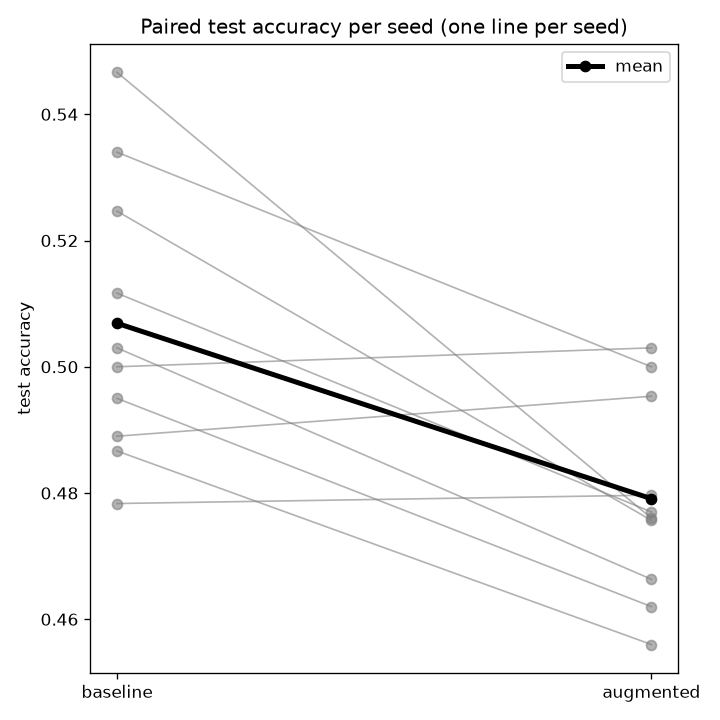

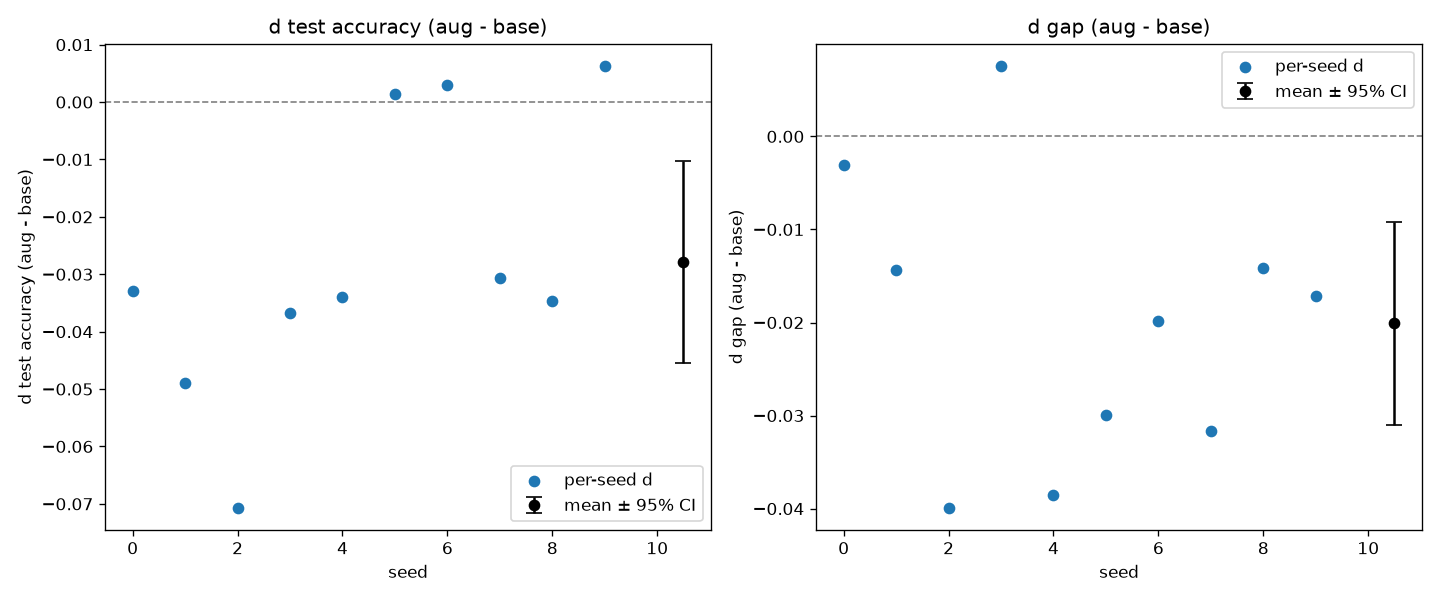

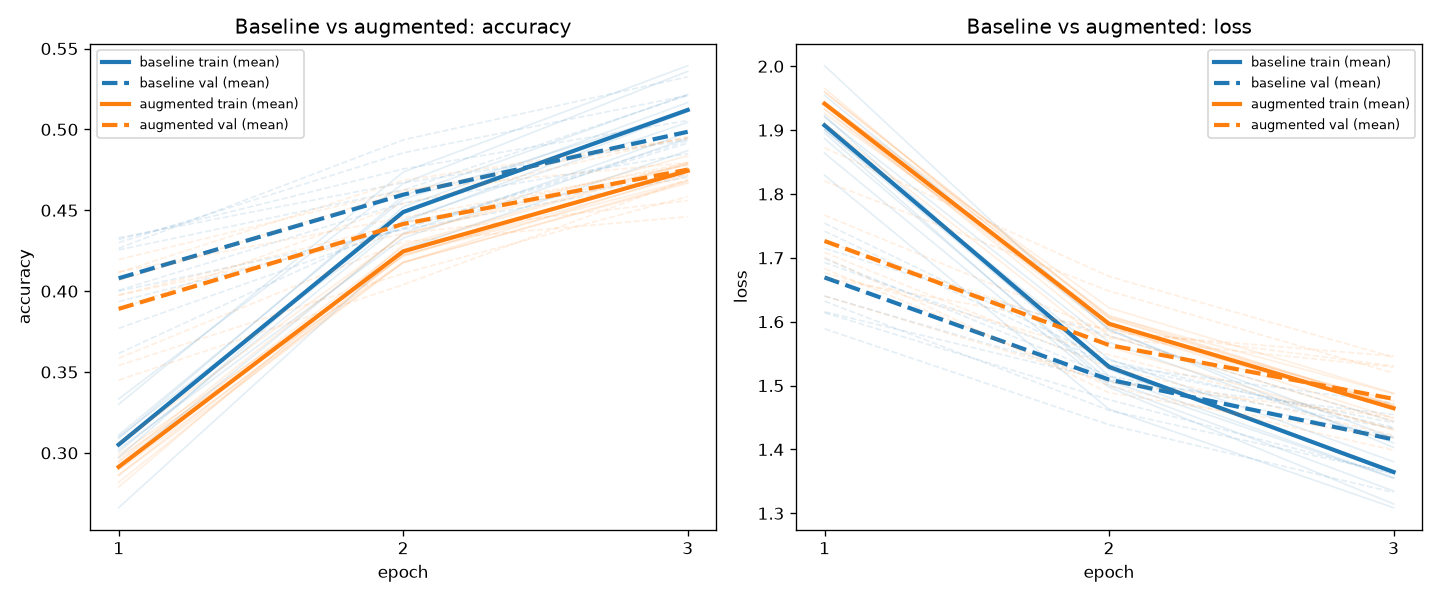

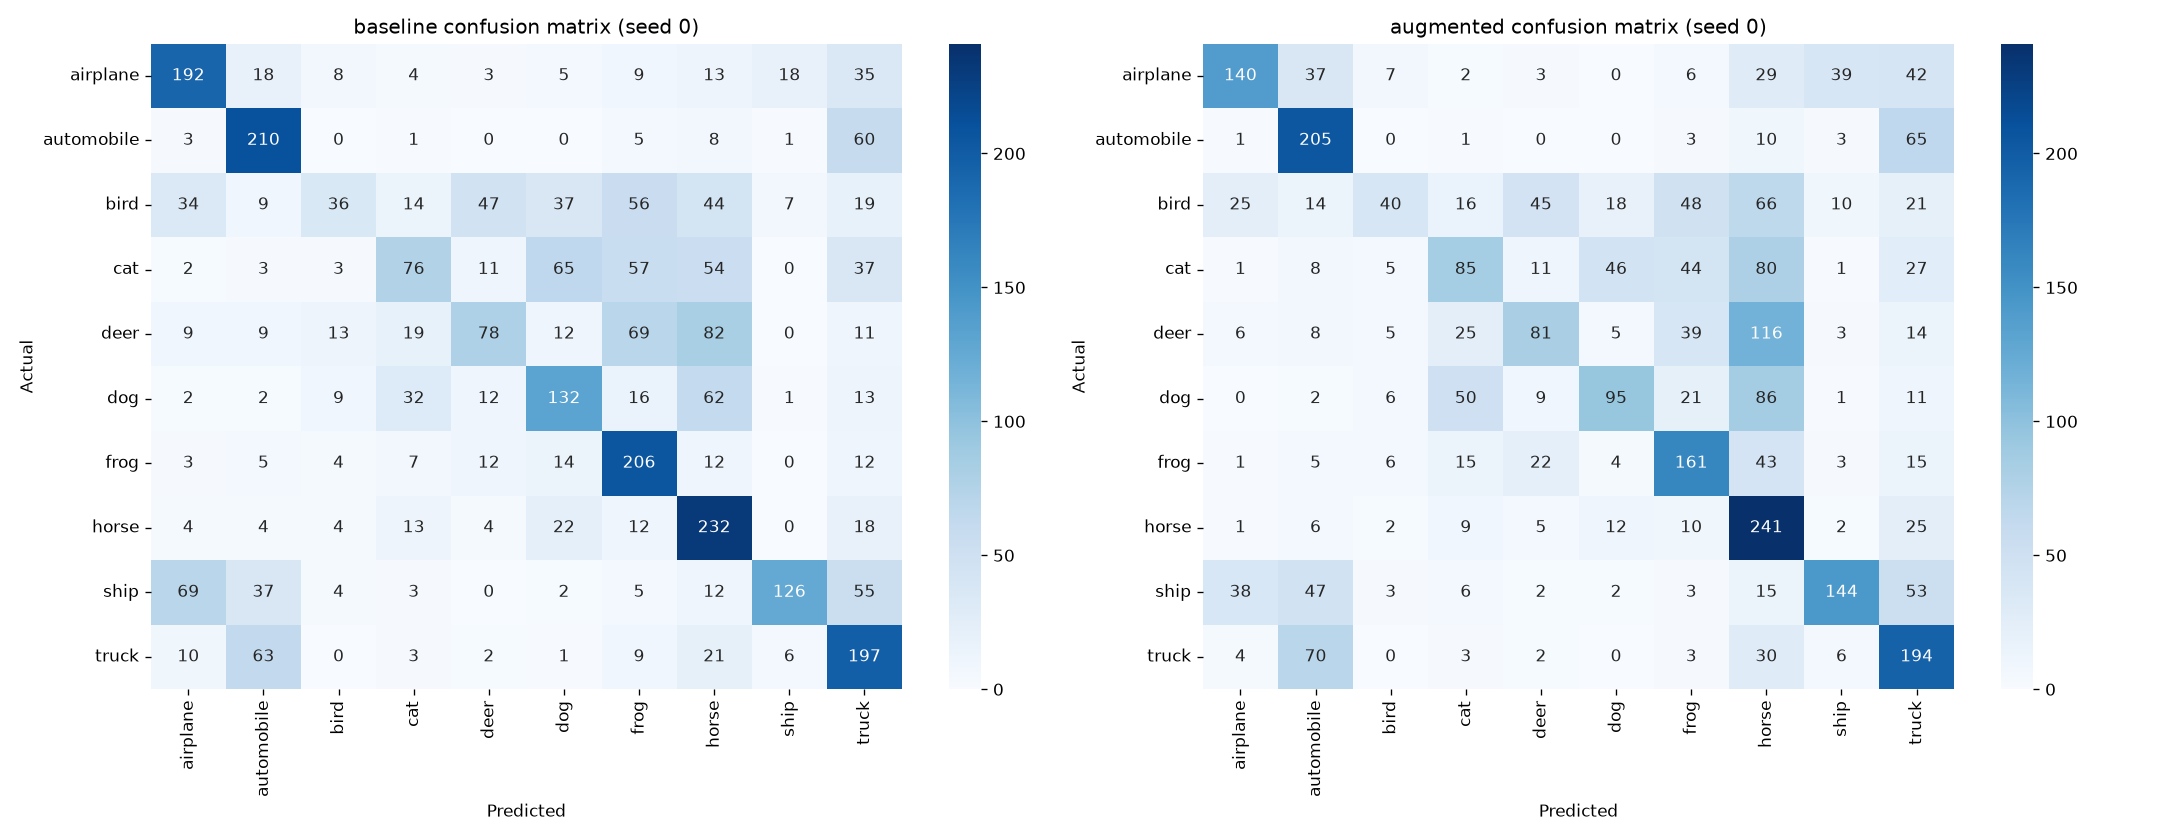

In [9]:
# --- Visuals: the four committed figures from the pre-registered run, rendered inline ---
for fn in ['fig_paired_slope.png', 'fig_difference_ci.png',
           'fig_curves_comparison.png', 'fig_confusion_side_by_side.png']:
    display(Image(filename=os.path.join(RESULTS_DIR, fn)))

## 13b. Per-class results

Macro recall averages ten per-class recalls with equal weight, which is exactly what conceals where a model succeeds and fails (§6). The table below reports per-class precision, recall and F1 for both conditions, averaged across the ten seeds, from `results/per_class_comparison.csv`.

In [12]:
# --- Per-class comparison (results/per_class_comparison.csv) ---
import pandas as pd

pc = pd.read_csv(os.path.join(RESULTS_DIR, 'per_class_comparison.csv'))
wide = pc.pivot(index='class_name', columns='condition',
                values=['precision', 'recall', 'f1'])
wide.columns = [f'{m}_{c}' for m, c in wide.columns]
wide['recall_change_pp'] = (wide['recall_augmented'] - wide['recall_baseline']) * 100
wide = wide.sort_values('recall_change_pp')

print('Per-class recall, baseline vs augmented (sorted by change)')
print(wide[['recall_baseline', 'recall_augmented', 'recall_change_pp',
            'precision_baseline', 'precision_augmented']].round(4).to_string())

Per-class recall, baseline vs augmented (sorted by change)
            recall_baseline  recall_augmented  recall_change_pp  precision_baseline  precision_augmented
class_name                                                                                              
deer                 0.3795            0.2795            -10.00              0.4648               0.4903
airplane             0.6456            0.5485             -9.71              0.5541               0.5827
bird                 0.2518            0.1719             -7.99              0.4412               0.4879
ship                 0.6125            0.5840             -2.85              0.6264               0.6156
cat                  0.2805            0.2669             -1.36              0.4027               0.3644
frog                 0.6589            0.6476             -1.13              0.5336               0.4700
truck                0.5324            0.5234             -0.90              0.5786               0.4

The loss is not evenly distributed. Augmentation falls hardest on classes that were already weakest: **bird recall drops from 0.252 to 0.172 — a 32% relative loss** — with deer (0.380 → 0.280) and aeroplane (0.646 → 0.549) also losing heavily. The single substantial gainer is **automobile (0.643 → 0.705)**, but its precision falls in step (0.624 → 0.545): the model predicts "automobile" more often and less accurately.

The pattern is coherent. Under a harder training signal the model retreats toward the visually distinctive vehicle classes and largely abandons the fine-grained animal distinctions. Xu et al. (2023) frame augmentation as expanding the *vicinity distribution* around each training example — the neighbourhood of inputs treated as sharing a label. A transform severe enough to push samples outside that neighbourhood is training the model on effectively mislabelled data, and the classes with the least distinctive low-resolution signal are the first to suffer.

## 13c. Reproducibility statement

Setting `tf.random.set_seed()` fixes weight initialisation but **does not** make this pipeline bit-reproducible. TensorFlow's CPU kernels do not guarantee a fixed floating-point reduction order across processes, and the resulting differences compound over training.

We can quantify this from our own runs. Comparing the committed pre-registered run against §9's re-execution — identical configuration, identical data, identical seeds — per-seed test accuracy differs by a mean of **1.57 pp** and by as much as **3.63 pp**.

Three consequences we report rather than conceal:

1. **Anyone re-running this notebook will obtain different per-seed numbers** from those in §10–§13. Both executions are documented; neither is presented as definitive.
2. **Our 3.77 pp noise floor has two components**, not one — variation *between* seeds and variation *within* a seed across executions. Our earlier framing attributed all of it to the first.
3. **The pairing achieved less variance reduction than intended.** The standard deviation of the paired differences was 2.46 pp against 2.72 pp expected if the two conditions were statistically independent, implying a correlation between paired runs of only *r* ≈ 0.19. Sharing a seed did not produce near-identical initialisations, most plausibly because inserting the augmentation layers alters the layer-construction order and therefore the random stream from which weights are drawn. Run-to-run noise also enters both arms independently and cannot cancel.

The corresponding fix, and our second stated next step, is to enforce true common initialisation: build one model, save its initial weights, and load them into both conditions before training. This would tighten every interval reported above without altering the design in any other respect.

## 14. Interpretation

### GROUP RESPONSE

**1. Focused research question**

Does basic image augmentation — horizontal flip with small rotation and zoom — change the test accuracy or the generalization gap of a fixed two-convolutional-layer CNN on a 10,000-image CIFAR-10 subset, relative to an identical unaugmented model trained on the same ten random seeds?

**2. Expected direction of change and reason**

We pre-registered a **non-directional** hypothesis for test accuracy and a **directional** hypothesis (decrease) for the generalization gap, before any augmented model was trained. The commitment is recorded in `HYPOTHESES_COMMITTED.md` and timestamped by its git commit.

We deliberately did **not** predict an accuracy improvement. Our baseline is *underfitting* at three epochs: validation loss falls monotonically in all runs, and validation accuracy sits above training accuracy for the first two epochs. Lin et al. (2024) establish that augmentation acts as an implicit spectral regularizer whose effect differs between fitting regimes — and a regularizer applied to a model that has not yet fit its training data has nothing to regularize. Predicting improvement would have contradicted our own control-condition evidence.

We did predict a directional decrease in the generalization gap, because reducing memorisation is augmentation's actual mechanism rather than a downstream side effect.

**3. Most important numeric result**

Across ten paired seeds, augmentation **reduced test accuracy by 2.78 percentage points** (95% CI [−4.54, −1.02]; paired *t*(9) = −3.573, *p* = 0.006 two-tailed; Wilcoxon *W* = 6.0, *p* = 0.027; Cohen's *d* = −1.13). Seven of ten seeds moved downward.

It simultaneously **reduced the generalization gap by 2.01 percentage points** (95% CI [−3.10, −0.92]; paired *t*(9) = −4.164, *p* = 0.0012 one-tailed; Wilcoxon *W* = 2.0, *p* = 0.0029; *d* = −1.32). Nine of ten seeds moved downward.

**Both pre-registered null hypotheses are rejected.** H₀₁ was non-directional, so the accuracy result is a two-tailed rejection rather than a confirmed prediction. H₀₂ was rejected in the predicted direction.

The single most important number, however, is a comparison: our accuracy effect of 2.78 pp is **smaller than the baseline's own run-to-run noise floor of 3.77 pp**. It reached significance through consistency across paired seeds, not through magnitude.

**Replication.** This notebook re-executes the entire paired experiment in §9 to demonstrate that it runs. Because TensorFlow's CPU kernels are not bit-deterministic across processes, that re-run constitutes a **second independent measurement on the same ten seeds**. Both findings replicated, more strongly: accuracy −3.75 pp (95% CI [−4.90, −2.60]; *t*(9) = −7.367, *p* < 0.0001; Wilcoxon *p* = 0.002; *d* = −2.33; **10 of 10** seeds negative) and gap −2.96 pp (*t*(9) = −10.891, *p* < 0.0001; **10 of 10** seeds negative).

We report the **committed pre-registered run** as our result and the re-run as a replication. We have deliberately *not* substituted the execution with the more favourable statistics: selecting among runs after seeing their p-values is precisely the practice pre-registration exists to prevent. Sections §10–§13 therefore report the committed run throughout, matching the numbers written above.

**4. What the confusion matrix or curves reveal**

Decomposing the generalization gap explains why two seemingly contradictory results are both true:

| | Baseline | Augmented | Change |
|---|---|---|---|
| Clean train accuracy | 0.5428 | 0.4993 | −4.35 pp |
| Clean validation accuracy | 0.4986 | 0.4752 | −2.34 pp |
| Gap | 0.0442 | 0.0241 | −2.01 pp |

**Both terms fell.** The gap narrowed because training accuracy collapsed toward validation accuracy, not because validation accuracy rose. A shrinking gap read in isolation would have suggested improved generalization; the opposite occurred.

The per-class breakdown shows the loss was not evenly distributed. Augmentation fell hardest on classes that were already weakest: **bird recall dropped from 0.252 to 0.172 — a 32% relative loss** — with deer (0.380 → 0.280) and aeroplane (0.646 → 0.549) also losing heavily. The one substantial gainer was **automobile (0.643 → 0.705)**, but its precision fell in step (0.624 → 0.545), meaning the model predicted "automobile" more often and less accurately. Under a harder training signal the model retreated toward the visually distinctive vehicle classes and largely abandoned bird.

**5. One supported conclusion**

Under a three-epoch training budget on this architecture and dataset, basic augmentation operated exactly as its mechanism predicts and still made the model worse. It compressed the train–validation gap — the signature of a regularizer — while reducing accuracy on every measure we recorded. This is consistent with Lin et al. (2024), who establish that augmentation acts as an implicit spectral regularizer whose effect is **regime-dependent**: our baseline was underfitting, with validation loss still falling at epoch 3, so restraint removed capacity the model had not yet used.

We conclude that augmentation is not a cost-free default. Its benefit is conditional on the model being in a regime where overfitting is the binding constraint, and diagnosing that regime should precede applying it.

**6. One limitation**

Our headline limitation is **run-to-run variance relative to effect size**. Training the identical architecture on identical data five times, varying only the weight-initialisation seed, produced test accuracies from 49.50% to 53.27% — a spread of **3.77 percentage points**, larger than most augmentation effects reported at this scale.

This is a documented property of neural network training, not an error in our procedure. Coakley & Gundersen (2026), across 18,600 training runs, report seed-only accuracy ranges of 1.48 pp (ResNet20) and 1.71 pp (ViT-S-8) on full CIFAR-10, and conclude that "model performance is not a single value, but rather a distribution." Åkesson et al. (2024), running one algorithm across 50 seeds, found the best seed statistically significantly outperformed between 0% and 76% of the others — from the *identical* algorithm. Seed variation alone manufactures apparent significance.

This is why we used a **paired design**: comparing conditions within each seed rather than across group means was intended to remove shared initialisation variance from the comparison. Our measured effect of 2.78 pp is smaller than this 3.77 pp noise floor, and reached significance only through consistency across seeds — which is precisely the situation the paired design exists to handle.

**Two caveats on our own numbers, both of which weaken us rather than help us.**

First, we predicted that a five-seed *range* would understate true variability, since range grows with sample size. Our own data confirms it: baseline test-accuracy standard deviation rose from 1.62 pp at five seeds to **2.21 pp at ten**.

Second, **fixing the random seed did not make our pipeline reproducible.** Re-executing the identical configuration on the identical data (§9 of this notebook) produced per-seed test accuracies differing from the committed run by a mean of **1.57 pp**, and by as much as **3.63 pp**. Seeding controls weight initialisation but not floating-point reduction order, which varies across processes. Anyone re-running this notebook will therefore obtain different per-seed numbers than the ones we report, and we document both executions rather than presenting either as definitive. A practical consequence: our 3.77 pp noise floor has **two** components — variation between seeds, and variation within a seed across executions — and our earlier analysis attributed all of it to the first.

Third, and relatedly, **our pairing achieved less variance reduction than intended.** The standard deviation of the paired differences was 2.46 pp, against 2.72 pp expected if the two conditions were statistically independent — implying a correlation between paired runs of only *r* ≈ 0.19. Sharing a random seed did *not* produce near-identical initialisations across conditions, most plausibly because inserting the augmentation layers changes the order in which layers are constructed and therefore the random stream from which weights are drawn. The pairing helped, but far less than a true common-initialisation design would have, and our confidence intervals are correspondingly wider than they need to be.

Secondary limitations: a single architecture and a single three-epoch budget, so we cannot say whether augmentation would help this model trained longer; and CIFAR-10's labels are themselves imperfect — Northcutt et al. (2021) demonstrate recoverable label errors in widely-used benchmarks, so our accuracies measure agreement with CIFAR-10's labels rather than with ground truth.

**7. One appropriate next step**

Run a **flip-only** condition against the same baseline on the same ten paired seeds. Because our augmented condition combines flip, rotation and zoom, the contrast between flip-only and the full moderate setting would isolate the contribution of rotation and zoom specifically — the components the low-resolution literature identifies as risky (Alomar et al., 2023). This directly tests whether the 2.78 pp accuracy loss we measured comes from the transform with a genuine domain invariance (flip, where a mirrored car is still a car) or from the ones that destroy pixel information at 32×32. Given that our largest per-class casualty was bird recall — down 32% in relative terms — we would also check whether that collapse survives the removal of rotation and zoom. The additional compute cost is approximately 80 seconds.

A second, cheaper improvement we would apply at the same time: **enforce true common initialisation** by building one model, saving its initial weights, and loading them into both conditions before training. Our observed *r* ≈ 0.19 shows the current seed-sharing approach does not achieve this, and fixing it would tighten every interval reported above without changing the design in any other respect.

### APA 7 references

See `05_References_APA7.md`.

### Claim boundary

Test performance on a small CIFAR-10 subset does not establish real-world readiness, fairness across populations, or reliability for images from a different setting. Roberts et al. (2021) systematically screened 2,212 machine-learning studies on COVID-19 imaging down to 62 that met quality criteria, and concluded that "none of the models have potential clinical utility due to methodological flaws and/or underlying biases" — despite high reported accuracies throughout. A single held-out split on a curated benchmark is weaker evidence still. We claim only what we measured: a difference, or absence of one, between two training configurations on this dataset, at this budget, under this architecture.

## 15. References

# References — APA 7

Every entry verified: journal article, version of record 2021 or later, SJR Q1 or Q2. **Open every DOI yourself before submitting.**

---

## The three required sources

**(a) Method — CNNs / data augmentation**

Ottoni, A. L. C., de Amorim, R. M., Novo, M. S., & Costa, D. B. (2023). Tuning of data augmentation hyperparameters in deep learning to building construction image classification with small datasets. *International Journal of Machine Learning and Cybernetics, 14*(1), 171–186. https://doi.org/10.1007/s13042-022-01555-1

**(b) Dataset / application — CIFAR-10 and image classification**

Alomar, K., Aysel, H. I., & Cai, X. (2023). Data augmentation in classification and segmentation: A survey and new strategies. *Journal of Imaging, 9*(2), Article 46. https://doi.org/10.3390/jimaging9020046

**(c) Limitations / validity / responsible use**

Roberts, M., Driggs, D., Thorpe, M., Gilbey, J., Yeung, M., Ursprung, S., Aviles-Rivero, A. I., Etmann, C., McCague, C., Beer, L., Weir-McCall, J. R., Teng, Z., Gkrania-Klotsas, E., Rudd, J. H. F., Sala, E., & Schönlieb, C.-B. (2021). Common pitfalls and recommendations for using machine learning to detect and prognosticate for COVID-19 using chest radiographs and CT scans. *Nature Machine Intelligence, 3*(3), 199–217. https://doi.org/10.1038/s42256-021-00307-0

> *Author list abbreviated. The paper has 50+ authors including the AIX-COVNET collaboration; APA 7 requires the first 19 followed by an ellipsis and the final author. Verify the full list on the publisher page before submitting.*

---

## Additional sources cited in the analysis

Coakley, K. L., & Gundersen, O. E. (2026). Measuring deep learning performance: An empirical study of performance distributions across architectures and tasks. *Scientific Reports, 16*, Article 20474. https://doi.org/10.1038/s41598-026-49656-z

Lin, C.-H., Kaushik, C., Dyer, E. L., & Muthukumar, V. (2024). The good, the bad and the ugly sides of data augmentation: An implicit spectral regularization perspective. *Journal of Machine Learning Research, 25*(91), 1–85. https://jmlr.org/papers/v25/22-1312.html

Northcutt, C. G., Jiang, L., & Chuang, I. L. (2021). Confident learning: Estimating uncertainty in dataset labels. *Journal of Artificial Intelligence Research, 70*, 1373–1411. https://doi.org/10.1613/jair.1.12125

Åkesson, J., Töger, J., & Heiberg, E. (2024). Random effects during training: Implications for deep learning-based medical image segmentation. *Computers in Biology and Medicine, 180*, Article 108944. https://doi.org/10.1016/j.compbiomed.2024.108944

Xu, M., Yoon, S., Fuentes, A., & Park, D. S. (2023). A comprehensive survey of image augmentation techniques for deep learning. *Pattern Recognition, 137*, Article 109347. https://doi.org/10.1016/j.patcog.2023.109347

Tan, M., Langenkämper, D., & Nattkemper, T. W. (2022). The impact of data augmentations on deep learning-based marine object classification in benthic image transects. *Sensors, 22*(14), Article 5383. https://doi.org/10.3390/s22145383

---

## Dataset

Krizhevsky, A. (2009). *Learning multiple layers of features from tiny images* [Technical report]. University of Toronto. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

> *The canonical CIFAR-10 citation. A technical report, not peer-reviewed — cite it as the dataset source, not as one of your three credible sources.*

---

## In-text citation quick reference

| Claim | Citation |
|---|---|
| Augmentation is a regularizer whose effect depends on the fitting regime | (Lin et al., 2024) |
| Rotation at low resolution destroys pixel information | (Alomar et al., 2023) |
| Stacking transforms can underperform selective choice | (Ottoni et al., 2023) |
| Augmentation benefit weakens as training-set size grows | (Tan et al., 2022) |
| Severe transforms push samples outside the class vicinity | (Xu et al., 2023) |
| Seed-only variation of 1.48–1.71 pp on CIFAR-10 across 100 seeds | (Coakley & Gundersen, 2026) |
| Significance from seed variation alone is unreliable | (Åkesson et al., 2024) |
| Benchmark labels contain recoverable errors | (Northcutt et al., 2021) |
| High accuracy does not establish real-world readiness | (Roberts et al., 2021) |

## 16. Conclusion

Under a three-epoch training budget on a 10,000-image CIFAR-10 subset, basic image augmentation behaved exactly as its mechanism predicts and still made the model worse. It compressed the train–validation gap — the signature of a regularizer — while reducing accuracy on every measure we recorded, because the baseline had not yet begun to overfit and therefore had nothing to regularize (Lin et al., 2024).

Three things we would want a reader to take from this notebook:

1. **A shrinking generalization gap is not self-evidently good.** The gap is a difference between two quantities and says nothing about their level. Reported alone, ours would have supported the opposite of the correct conclusion.
2. **Effect size must be read against measured noise, not against zero.** Our 2.78 pp effect is smaller than the baseline's own 3.77 pp run-to-run spread. It is credible because ten paired seeds moved consistently, not because it is large.
3. **Augmentation is not a cost-free default.** Its benefit is conditional on the model being in a regime where overfitting is the binding constraint, and diagnosing that regime should precede applying it.

What this notebook does **not** establish: that augmentation fails to help this architecture trained longer, that it fails on other datasets or resolutions, or anything whatever about fairness, robustness, or readiness for deployment. Roberts et al. (2021) systematically screened 2,212 machine-learning imaging studies down to 62 meeting quality criteria and concluded that "none of the models have potential clinical utility due to methodological flaws and/or underlying biases" — despite uniformly high reported accuracies. A single held-out split on a curated benchmark is weaker evidence still.